In [1]:
import sys
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import struct


import funciones_aux as fau

import funciones_dsa as fun_dsa
import funciones_dsa_unilateral as fun_dsa_u
import funciones_dsa_bilateral as fun_dsa_b

import funciones_plot_dsa as fun_plot

from scipy.signal import welch
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from scipy.stats import pearsonr, spearmanr


# OG

#### Archivo f_a

In [2]:
ruta_base_advanced = "../data/data_bis_advanced"

archivos_fa = fau.localizar_archivos(ruta_base_advanced, "DH*", "*.f_a")
ruta_fa = archivos_fa[0]
print("Archivo seleccionado:", ruta_fa)

tiempo_fa_unilat, dsa_unilat = fau.cargar_fa_directo(ruta_fa, escalar_db=True)

print("Dimensiones de la matriz:", dsa_unilat.shape)
print("Frecuencias:", dsa_unilat.columns.min(), "a", dsa_unilat.columns.max(), "Hz")

Se han encontrado 2 archivos *.f_a
Archivo seleccionado: ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.f_a
Dimensiones de la matriz: (2119, 60)
Frecuencias: 0.5 a 30.0 Hz


#### Archivo spa

In [3]:
ruta_spa_unilat = "../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.spa"


df_spa_raw = fau.procesar_spa(ruta_spa_unilat)
df_spa_unilat = fun_dsa_u.limpiar_spa_unilateral(df_spa_raw)

## Unión de los 2

In [4]:
df_merge_hor = fun_dsa.alinear_spa_con_tiempo(tiempo_fa_unilat, df_spa_unilat)
sef_hor = df_merge_hor["SEF08"]
mf_hor = df_merge_hor["MEDFRQ08"]

dsa_plot_hor, mask_total_hor = fun_dsa.preparar_dsa_con_mask(tiempo_fa_unilat, dsa_unilat, df_merge_hor)

# las matrices que vienen de la f_a suelen mostrar valores entre el 49 y 94
matriz_hor, vmin_hor, vmax_hor, norm_hor, cmap_hor = fun_dsa.preparar_escala_color_dsa(dsa_plot_hor, vmin=49, vmax=94, gamma=1)

In [5]:
cols_freq = [c for c in dsa_plot_hor.columns]


print(np.nanmin(dsa_plot_hor[cols_freq].values))
print(np.nanmax(dsa_plot_hor[cols_freq].values))

print(np.nanpercentile(dsa_plot_hor[cols_freq].values, 2))
print(np.nanpercentile(dsa_plot_hor[cols_freq].values, 99.5))

55.61
103.02
70.0
96.87


# Procesado

In [6]:
archivo_r2a = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"

### Reconstrucción desde EEG crudo

In [7]:
df_eeg = fun_dsa_u.leer_r2a(
    archivo_r2a,
    fs=128,
    escala_uv=0.0511
)

# se pierde un segundo por el uso de ventanas de 2 segundos con etiqueta temporal en el centro
""" 
La función no calcula una DSA para cada muestra aislada ni para cada segundo independiente. 
Calcula una DSA por ventanas completas de 2 segundos (usando 256 muestras).
La ventana avanza cada segundo (cada 128 muestras).

Resultado: Cada fila de la DSA final no sale de un único segundo, sino de una ventana de 2 segundos.


Por eso, con ventanas de 2 segundos y paso de 1 segundo, si tienes un registro de N segundos, se obtienen aproximadamente:
N - 1 filas espectrales. 
No se obtienen N filas, porque no se puede calcular una ventana completa de 2 segundos centrada 
en todos los segundos extremos sin salirse del registro.
"""

df_dsa_canal1, frecuencias_c1 = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg,
    "canal_1_uV",
    fs=128,
    ventana_seg=1,
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

df_dsa_canal2, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg,
    "canal_2_uV",
    fs=128,
    ventana_seg=1,
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

# columnas del dF generado después de la conversión por FFT -> las frecuencias
cols_freq = [c for c in df_dsa_canal1.columns if c != "tiempo_s"]

# copia del dF del canal 1 para tener esa estructura
df_dsa_media = df_dsa_canal1.copy()

# media (en float) de las potencias (en uV) de los 2 canales
# en función de las frecuencias 
pot_media = (
    df_dsa_canal1[cols_freq].to_numpy(dtype=float) +
    df_dsa_canal2[cols_freq].to_numpy(dtype=float)
) / 2

# array de los nombres de las columnas pasados a float
frecuencias_float = np.array([float(c) for c in cols_freq])

# calcular sef y mef solo para la dsa reconstruida del eeg 
# (basado en la potencia en uV)
sef_eeg, mef_eeg = fun_dsa.calcular_sef_mef_desde_potencia(
    potencia=pot_media,
    frecuencias=frecuencias_float,
    percentil_sef=0.95,
    percentil_mef=0.50
)

# Como después añadimos una fila inicial NaN a la DSA reconstruida,
# también añadimos un NaN inicial a SEF y MEF para que tengan la misma longitud.
sef_eeg_plot = pd.Series(
    np.r_[sef_eeg],
    name="SEF08"
)

mef_eeg_plot = pd.Series(
    np.r_[mef_eeg],
    name="MEDFRQ08"
)


# Conversión a dB usando la referencia documentada de la DSA BIS:
# 0.0001 µV RMS
ref_uv_rms = 0.0001

df_dsa_media[cols_freq] = 10 * np.log10(
    (pot_media + 1e-12) / (ref_uv_rms ** 2)
)

""" 
Desde aquí tenemos:
 - df_dsa_media: dataframe con la estructura de la dsa
     - cols_freq: los nombres de las columnas en string -> solo las frecuencias
     - el contenido de cada columna se sobreescribe con el resultado del cálculo
"""

' \nDesde aquí tenemos:\n - df_dsa_media: dataframe con la estructura de la dsa\n     - cols_freq: los nombres de las columnas en string -> solo las frecuencias\n     - el contenido de cada columna se sobreescribe con el resultado del cálculo\n'

In [8]:
print(np.nanmin(df_dsa_media[cols_freq].values))
print(np.nanmax(df_dsa_media[cols_freq].values))

print(np.nanpercentile(df_dsa_media[cols_freq].values, 2))
print(np.nanpercentile(df_dsa_media[cols_freq].values, 99.5))

42.06825408227754
129.82281516998063
72.35147912223097
114.70939350044868


### Adaptación temporal, máscara y plot de DSA EEG

In [9]:
df_spa_unilat, hora_inicio = fun_dsa.obtener_hora_inicio_desde_spa(
    df_spa_unilat
)

tiempo_eeg, dsa_eeg = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_media,
    frecuencias=frecuencias_c1,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=False
)

df_merge_plot = fun_dsa.alinear_spa_con_tiempo(
    tiempo=tiempo_eeg,
    df_spa=df_spa_unilat
)

df_merge_plot["SEF08"] = sef_eeg_plot.values
df_merge_plot["MEDFRQ08"] = mef_eeg_plot.values

_, mask_total = fun_dsa.preparar_dsa_con_mask(
    tiempo=tiempo_eeg,
    dsa=dsa_eeg,
    df_merge=df_merge_plot,
    umbral_sqi=15,
    umbral_ceros=0.9
)

mask_comun = mask_total.copy()

# en las reconstrucciones se utilizan como valores mínimos y máximos 
# los percentiles más ajustados para replicar el color


In [10]:
print(df_spa_unilat)

                    Time  SEF08  MEDFRQ08  SQI10  TOTPOW08  EMGLOW01  SR12  \
0    2026-03-04 10:35:21    NaN       NaN    0.0       NaN      56.9   NaN   
1    2026-03-04 10:35:22    NaN       NaN    0.0       NaN      54.1   NaN   
2    2026-03-04 10:35:23    NaN       NaN    0.0       NaN      58.4   NaN   
3    2026-03-04 10:35:24    NaN       NaN    0.0       NaN      57.6   NaN   
4    2026-03-04 10:35:25    NaN       NaN    0.8       NaN      60.4   NaN   
...                  ...    ...       ...    ...       ...       ...   ...   
2114 2026-03-04 11:10:35   20.3       6.3   51.3      69.4      51.6   0.0   
2115 2026-03-04 11:10:36   20.3       6.3   51.3      69.4      52.2   0.0   
2116 2026-03-04 11:10:37   20.1       6.1   50.6      69.5      53.9   0.0   
2117 2026-03-04 11:10:38   19.7       5.7   48.6      69.7      54.7   0.0   
2118 2026-03-04 11:10:39   19.2       5.2   45.7      69.9      54.7   0.0   

       ST  DB13U01      ARTF2  BURST  
0     0.0      NaN      

In [11]:
# DSA original f_a con máscara común

""" 
Copia de la dsa proveniente del f_a para incluirla en el plot
 - .loc[mask_comun.values, :]: selecciona todas las filas donde mask_comun vale True, y todas las columnas de frecuencia.
 - np.nan: como el colormap pinta los NaN en blanco, esas filas aparecerán como bandas blancas.
"""

dsa_fa_plot = dsa_unilat.copy()
dsa_fa_plot.loc[mask_comun.values, :] = np.nan



# DSA reconstruida directa con máscara común

""" 
Copia de la dsa proveniente del eeg para incluirla en el plot
 - .loc[mask_comun.values, :]: selecciona todas las filas donde mask_comun vale True, y todas las columnas de frecuencia.
 - np.nan: como el colormap pinta los NaN en blanco, esas filas aparecerán como bandas blancas.
"""

dsa_eeg_directa_plot = dsa_eeg.copy()
dsa_eeg_directa_plot.loc[mask_comun.values, :] = np.nan

### Comprobar que ambas matrices están alineadas

In [12]:
print("DSA f_a:", dsa_fa_plot.shape)
print("DSA EEG:", dsa_eeg_directa_plot.shape)

print("¿Tiempos iguales?")
print((tiempo_fa_unilat.reset_index(drop=True) == tiempo_eeg.reset_index(drop=True)).all())

print("Rango DSA EEG reconstruida:")
print(np.nanmin(dsa_eeg_directa_plot.values), np.nanmax(dsa_eeg_directa_plot.values))

print("Rango DSA f_a:")
print(np.nanmin(dsa_fa_plot.values), np.nanmax(dsa_fa_plot.values))

DSA f_a: (2119, 60)
DSA EEG: (2119, 60)
¿Tiempos iguales?
True
Rango DSA EEG reconstruida:
45.91220504499371 129.82281516998063
Rango DSA f_a:
55.61 103.02


## Preparar escalas de color de f_a y EEG directa

In [13]:
matriz_fa, vmin_fa, vmax_fa, norm_fa, cmap_fa = fun_dsa.preparar_escala_color_dsa(
    dsa_fa_plot,
    vmin=49,
    vmax=94,
    gamma=1
)

matriz_eeg, vmin_eeg, vmax_eeg, norm_eeg, cmap_eeg = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_directa_plot,
    gamma=0.4
)

### Comparación base

In [14]:
dsa_eeg_comparacion, dsa_fa_comparacion = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_directa_plot,
    dsa_fa_plot
)

dsa_eeg_z = fun_dsa.zscore_global(dsa_eeg_comparacion)
dsa_fa_z = fun_dsa.zscore_global(dsa_fa_comparacion)

metricas_base = fun_dsa.comparar_dsa_global(
    dsa_eeg_z,
    dsa_fa_z
)

metricas_base

{'n_valores_comparados': 118380,
 'MAE': np.float64(0.8753365527246261),
 'RMSE': np.float64(1.1239939748747863),
 'bias_B_menos_A': np.float64(1.3665853191236663e-15),
 'Pearson': np.float64(0.3683187722225891),
 'Spearman': np.float64(0.29411979746867667)}

### Correlación por frecuencia

In [15]:
df_corr_freq = fun_dsa.correlacion_por_frecuencia(
    dsa_eeg_z,
    dsa_fa_z
)

"""plt.figure(figsize=(12, 4))

plt.plot(
    df_corr_freq["frecuencia_Hz"],
    df_corr_freq["correlacion"],
    marker="o"
)

for f in [4, 8, 13]:
    plt.axvline(f, color="gray", linestyle="--", linewidth=1, alpha=0.6)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Correlación")
plt.title("Correlación por frecuencia entre DSA EEG y DSA f_a")
plt.tight_layout()
plt.show()"""

'plt.figure(figsize=(12, 4))\n\nplt.plot(\n    df_corr_freq["frecuencia_Hz"],\n    df_corr_freq["correlacion"],\n    marker="o"\n)\n\nfor f in [4, 8, 13]:\n    plt.axvline(f, color="gray", linestyle="--", linewidth=1, alpha=0.6)\n\nplt.axhline(0, color="gray", linestyle="--", linewidth=1)\n\nplt.xlabel("Frecuencia (Hz)")\nplt.ylabel("Correlación")\nplt.title("Correlación por frecuencia entre DSA EEG y DSA f_a")\nplt.tight_layout()\nplt.show()'

### Suavizado temporal

Suavizado temporal de la DSA reconstruida desde EEG

La DSA reconstruida desde el EEG crudo viene de un cálculo directo y produce una DSA con muchos cambios rápidos. 

La DSA del f_a del BIS se ve más suave y no cambia tan bruscamente de segundo a segundo. Sugiere que el BIS podría aplicar algún tipo de promedio temporal interno antes de guardar el f_a.

### Suavizado + shift

In [16]:
ventanas_sp_smooth = [5, 10, 30, 60]

df_suav_shift = fun_dsa.probar_suavizado_y_shifts(
    dsa_eeg_comparacion,
    dsa_fa_comparacion,
    ventanas_suavizado=ventanas_sp_smooth,
    shifts=range(-60, 61)
)

df_suav_shift.sort_values("Pearson", ascending=False).head(7)

,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
313,30,11,0.756067,0.729172,0.530894,0.697365
314,30,12,0.755670,0.728223,0.531748,0.697929
312,30,10,0.755553,0.728827,0.531156,0.698101
315,30,13,0.754286,0.725853,0.533840,0.699892
311,30,9,0.754103,0.727141,0.532456,0.700154
316,30,14,0.751863,0.722055,0.537064,0.703296
310,30,8,0.751744,0.724153,0.534811,0.703519


In [17]:
df_suav_shift.sort_values("Spearman", ascending=False).head(7)

,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
313,30,11,0.756067,0.729172,0.530894,0.697365
312,30,10,0.755553,0.728827,0.531156,0.698101
314,30,12,0.755670,0.728223,0.531748,0.697929
311,30,9,0.754103,0.727141,0.532456,0.700154
315,30,13,0.754286,0.725853,0.533840,0.699892
310,30,8,0.751744,0.724153,0.534811,0.703519
316,30,14,0.751863,0.722055,0.537064,0.703296


### Tabla resumen final

La variante que mejor aproximó la DSA reconstruida desde EEG crudo a la DSA del archivo `f_a` fue la media de potencias de los dos canales, calculada a partir de densidad espectral de potencia y convertida posteriormente a dB. 

Tras aplicar un suavizado temporal causal de 30 s y un desplazamiento temporal de 10 u 11 s, se obtuvo una correlación de Pearson de aproximadamente 0.706 y una correlación de Spearman de aproximadamente 0.704. 

Esto sugiere que el archivo `f_a` incorpora información espectral de ambos canales, así como procesamiento temporal suavizado y un posible retardo asociado al cálculo interno del monitor BIS.

In [18]:
mejor_pearson = df_suav_shift.sort_values("Pearson", ascending=False).iloc[0]
mejor_spearman = df_suav_shift.sort_values("Spearman", ascending=False).iloc[0]

df_resumen_final = pd.DataFrame([
    {
        "criterio": "Mejor Pearson",
        "suavizado_s": mejor_pearson["suavizado_s"],
        "shift_s": mejor_pearson["shift_s"],
        "Pearson": mejor_pearson["Pearson"],
        "Spearman": mejor_pearson["Spearman"],
        "MAE": mejor_pearson["MAE"],
        "RMSE": mejor_pearson["RMSE"],
    },
    {
        "criterio": "Mejor Spearman",
        "suavizado_s": mejor_spearman["suavizado_s"],
        "shift_s": mejor_spearman["shift_s"],
        "Pearson": mejor_spearman["Pearson"],
        "Spearman": mejor_spearman["Spearman"],
        "MAE": mejor_spearman["MAE"],
        "RMSE": mejor_spearman["RMSE"],
    }
])

df_resumen_final

,criterio,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
0,Mejor Pearson,30.0,11.0,0.756067,0.729172,0.530894,0.697365
1,Mejor Spearman,30.0,11.0,0.756067,0.729172,0.530894,0.697365


## Comparación entre la DSA reconstruida desde EEG crudo y la DSA exportada por el BIS

El objetivo de este bloque es evaluar de forma objetiva la similitud entre la matriz tiempo-frecuencia obtenida desde el EEG crudo y la matriz exportada por el monitor BIS.

Se ha desarrollado un sistema comparador para evaluar la similitud entre la DSA reconstruida desde el EEG crudo y la DSA contenida en el archivo .f_a.

Este sistema compara ambas matrices tanto visual como cuantitativamente. 
Para ello:
 - Las matrices se alinean temporal y frecuencialmente
 - Se eliminan los tramos no válidos mediante una máscara común
 - Se nrmalizan mediante el z - score para compensar diferencias de escala
 - Se calculan métricas de similitud: Correlación de Pearson, Correlación de Spearman, MAE y RMSE.
 
Además, el sistema ha permitido evaluar variantes de procesamiento, como el suavizado temporal, para determinar qué configuración reproduce mejor la matriz construida a partir del archivo .f_a.

------------------------------------------------------------------------------------------------
### Cambio de los colores en la figura final y funcionamiento del z-score

En la figura comparativa final, los colores no representan los valores absolutos originales de cada matriz, sino valores normalizados mediante el z-score. 

Esta normalización transforma cada celda según su desviación respecto a la media global de su propia matriz. Por tanto, los colores indican si una región presenta una intensidad relativamente alta o baja dentro de cada DSA. 

Al emplear una escala común para las tres matrices normalizadas, la figura permite comparar patrones relativos, aunque el aspecto cromático difiera del observado en las tres representaciones individuales.

$$
Z(t,f)=\frac{D(t,f)-\mu_D}{\sigma_D}
$$

Donde: 
 - D(t,f) es el valor de la DSA en el instante \(t\) 
 - la frecuencia \(f\)
 - $\mu_D$ es la media global de la matriz 
 - $\sigma_D$ su desviación típica.

### Media de potencia de los dos canales

La señal r2a contiene dos canales EEG. Se evaluaron reconstrucciones usando canal 1, canal 2 y una combinación de ambos.

La mejor similitud se obtuvo al promediar las densidades espectrales de potencia de ambos canales en escala lineal y convertir posteriormente a dB.

Esta estrategia es preferible a promediar directamente los dB, ya que la escala logarítmica no es lineal. El resultado sugiere que la DSA del f_a podría incorporar información espectral procedente de ambos canales.

$$
P_{\text{media}}(t,f)=\frac{P_1(t,f)+P_2(t,f)}{2}
$$

$$
D_{\text{media}}(t,f)=10\log_{10}\left(P_{\text{media}}(t,f)\right)
$$

-----------------------------------------------------------------------------------------------

El sistema es un comparador porque no solo genera una imagen:
- alinea las matrices;
- aplica una máscara de validez común;
- normaliza las escalas;
- calcula correlaciones y errores;
- permite probar variantes de reconstrucción;
- identifica la configuración que maximiza la similitud;
- muestra una comparación visual final.

## Suavizado limpio

In [19]:
suavizado_final = 30

dsa_eeg_suav = dsa_eeg.copy().rolling(
    window=suavizado_final,
    min_periods=1,
    center=False
).mean()

In [20]:

# máscara común al final
dsa_eeg_suav_plot = dsa_eeg_suav.copy()
dsa_eeg_suav_plot.loc[mask_comun.values, :] = np.nan

matriz_opt, vmin_opt, vmax_opt, norm_opt, cmap_opt = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_suav_plot,
    gamma=0.25
)

## Comprobación de bandas blancas

In [21]:
mask_blanca_directa = dsa_eeg_directa_plot.isna().all(axis=1)
mask_blanca_suav = dsa_eeg_suav_plot.isna().all(axis=1)

print("bandas blancas directa vs suavizada")
print((mask_blanca_directa == mask_blanca_suav).all())

print("Diferencias:")
print((mask_blanca_directa != mask_blanca_suav).sum())

bandas blancas directa vs suavizada
True
Diferencias:
0


## Al haber recortado 10 segundos


In [22]:
shift_final = 11

# matriz vacía del mismo tamaño que la DSA suavizada original
dsa_eeg_suav_shift_full = pd.DataFrame(
    np.nan,
    index=dsa_eeg_suav.index,
    columns=dsa_eeg_suav.columns
)

# Desplazar la DSA suavizada hacia delante:
# las filas originales 0:-shift pasan a ocupar las filas shift:
dsa_eeg_suav_shift_full.iloc[shift_final:, :] = dsa_eeg_suav.iloc[:-shift_final, :].to_numpy()

# Aplicar la máscara común sobre la línea temporal original completa
dsa_eeg_suav_shift_full.loc[mask_comun.values, :] = np.nan

# Preparar escala de color
matriz_opt_desfase_full, vmin_opt_desfase_full, vmax_opt_desfase_full, norm_opt_desfase_full, cmap_opt_desfase_full = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_suav_shift_full,
    gamma=0.25
)

print("Tiempo:", len(tiempo_fa_unilat))
print("f_a:", matriz_hor.shape)
print("shift full:", matriz_opt_desfase_full.shape)

Tiempo: 2119
f_a: (2119, 60)
shift full: (2119, 60)


## Comprobación forma DSA

In [23]:
print("DSA f_a:", dsa_fa_plot.shape)
print("DSA EEG:", dsa_eeg_directa_plot.shape)
print("DSA suavizada:", dsa_eeg_suav_plot.shape)
print("DSA shift:", dsa_eeg_suav_shift_full.shape)

print(f"\n¿Tiempos iguales?")
print((tiempo_fa_unilat.reset_index(drop=True) == tiempo_eeg.reset_index(drop=True)).all())

print(f"\nRango DSA EEG reconstruida:")
print(np.nanmin(dsa_eeg_directa_plot.values), np.nanmax(dsa_eeg_directa_plot.values))

print(f"\nRango DSA f_a:")
print(np.nanmin(dsa_fa_plot.values), np.nanmax(dsa_fa_plot.values))

print(f"\nRango DSA suavizada:")
print(np.nanmin(dsa_eeg_suav_plot.values), np.nanmax(dsa_eeg_suav_plot.values))

print(f"\nRango DSA suavizada + shift:")
print(np.nanmin(dsa_eeg_suav_shift_full.values), np.nanmax(dsa_eeg_suav_shift_full.values))

DSA f_a: (2119, 60)
DSA EEG: (2119, 60)
DSA suavizada: (2119, 60)
DSA shift: (2119, 60)

¿Tiempos iguales?
True

Rango DSA EEG reconstruida:
45.91220504499371 129.82281516998063

Rango DSA f_a:
55.61 103.02

Rango DSA suavizada:
74.97351024682108 111.82849983799943

Rango DSA suavizada + shift:
74.97351024682108 111.82849983799943


# COMPARACIÓN FINAL

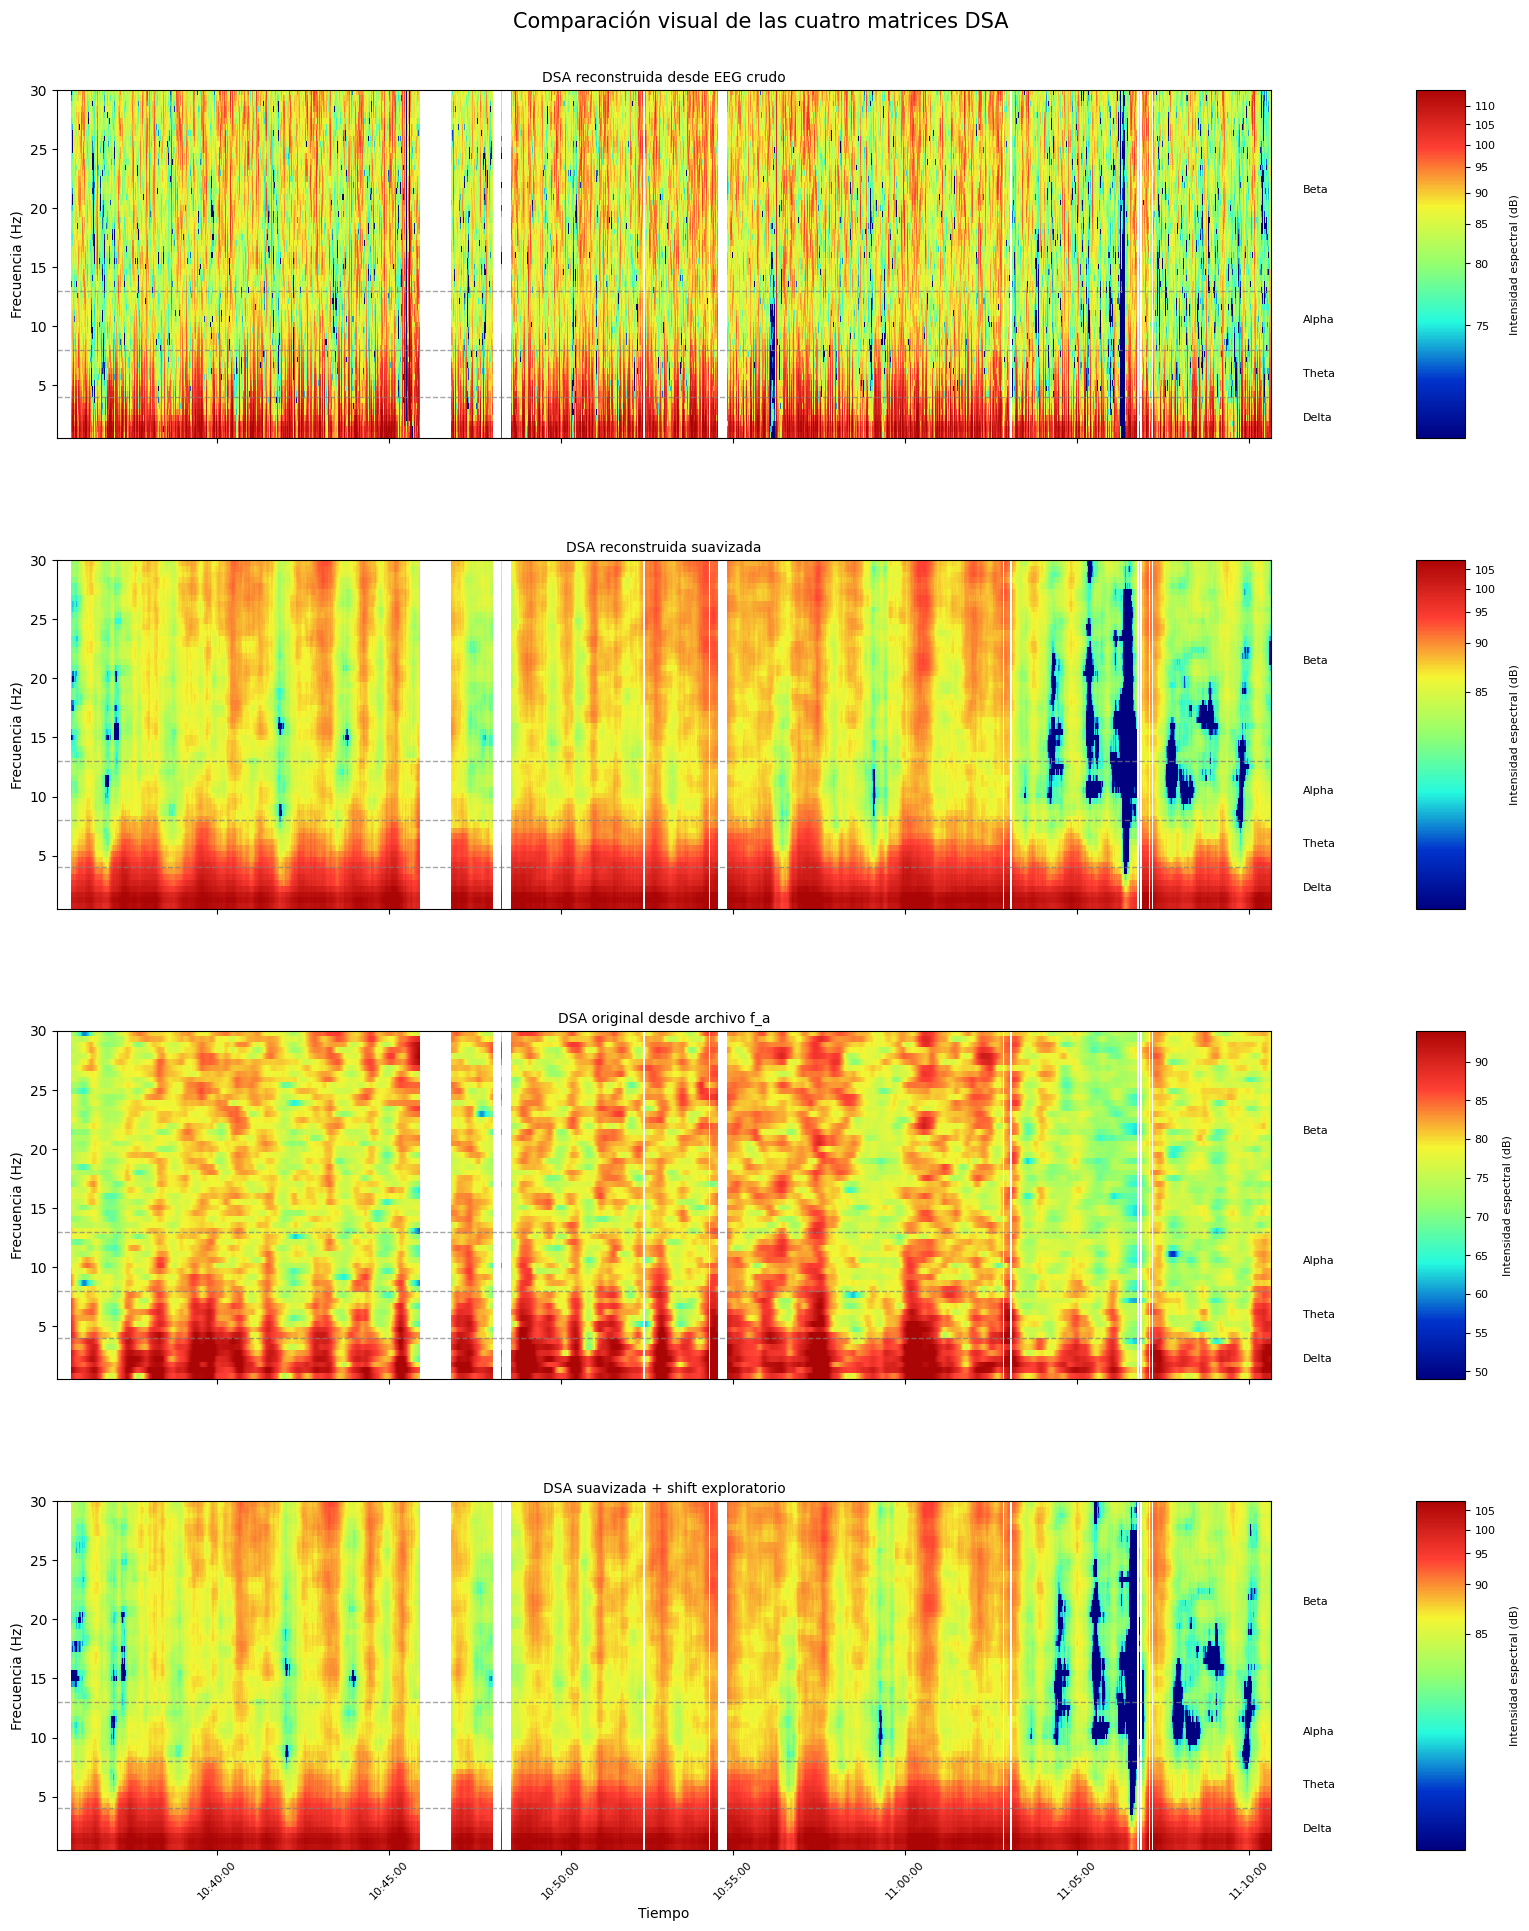

In [24]:
paneles = [
    
    {
        "tiempo": tiempo_eeg,
        "frecuencias": frecuencias_c1,
        "matriz": matriz_eeg,
        "norm": norm_eeg,
        "cmap": cmap_eeg,
        "df_merge": df_merge_plot,
        "titulo": "DSA reconstruida desde EEG crudo",
        "etiqueta_colorbar": "Intensidad espectral (dB)",
        "mask_total": mask_comun
    },
    {
        "tiempo": tiempo_eeg,
        "frecuencias": frecuencias_c1,
        "matriz": matriz_opt,
        "norm": norm_opt,
        "cmap": cmap_opt,
        "df_merge": df_merge_plot,
        "titulo": "DSA reconstruida suavizada",
        "etiqueta_colorbar": "Intensidad espectral (dB)",
        "mask_total": mask_comun
    },
    {
        "tiempo": tiempo_fa_unilat,
        "frecuencias": dsa_fa_plot.columns.astype(float),
        "matriz": matriz_fa,
        "norm": norm_fa,
        "cmap": cmap_fa,
        "df_merge": df_merge_hor,
        "titulo": "DSA original desde archivo f_a",
        "etiqueta_colorbar": "Intensidad espectral (dB)",
        "mask_total": mask_comun
    },
    {
        "tiempo": tiempo_eeg,
        "frecuencias": frecuencias_c1,
        "matriz": matriz_opt_desfase_full,
        "norm": norm_opt_desfase_full,
        "cmap": cmap_opt_desfase_full,
        "df_merge": df_merge_plot,
        "titulo": "DSA suavizada + shift exploratorio",
        "etiqueta_colorbar": "Intensidad espectral (dB)",
        "mask_total": mask_comun
    }
]

fig_grid, axes_grid = fun_dsa.plot_cuadricula_4_dsa(
    paneles,
    titulo_general="Comparación visual de las cuatro matrices DSA"
)

# Cálculo de SEF / MEF propios

In [27]:
# ============================================================
# SEF / MEF propios para cada representación
# ============================================================

suavizado_final=30

# 1. SEF/MEF de referencia del BIS, extraídos del .spa
sef_fa_spa = df_merge_hor["SEF08"].copy()
mef_fa_spa = df_merge_hor["MEDFRQ08"].copy()


# 2. SEF/MEF de la DSA reconstruida directa desde EEG
frecuencias_float = np.array([float(c) for c in cols_freq])

sef_eeg, mef_eeg = fun_dsa.calcular_sef_mef_desde_potencia(
    potencia=pot_media,
    frecuencias=frecuencias_float,
    percentil_sef=0.95,
    percentil_mef=0.50
)

sef_eeg_plot = pd.Series(np.r_[sef_eeg], name="SEF08")
mef_eeg_plot = pd.Series(np.r_[mef_eeg], name="MEDFRQ08")

df_merge_eeg = df_merge_plot.copy()
df_merge_eeg["SEF08"] = sef_eeg_plot.values
df_merge_eeg["MEDFRQ08"] = mef_eeg_plot.values


# 3. SEF/MEF de la DSA reconstruida suavizada
df_pot_media = pd.DataFrame(pot_media, columns=cols_freq)

df_pot_media_suav = df_pot_media.rolling(
    window=suavizado_final,
    min_periods=1,
    center=False
).mean()

sef_eeg_suav, mef_eeg_suav = fun_dsa.calcular_sef_mef_desde_potencia(
    potencia=df_pot_media_suav.to_numpy(dtype=float),
    frecuencias=frecuencias_float,
    percentil_sef=0.95,
    percentil_mef=0.50
)

sef_eeg_suav_plot = pd.Series(np.r_[sef_eeg_suav], name="SEF08")
mef_eeg_suav_plot = pd.Series(np.r_[mef_eeg_suav], name="MEDFRQ08")

df_merge_suav = df_merge_plot.copy()
df_merge_suav["SEF08"] = sef_eeg_suav_plot.values
df_merge_suav["MEDFRQ08"] = mef_eeg_suav_plot.values


# 4. SEF/MEF de la DSA suavizada + shift, manteniendo duración original
df_merge_suav_shift_full = df_merge_suav.copy()

df_merge_suav_shift_full["SEF08"] = np.nan
df_merge_suav_shift_full["MEDFRQ08"] = np.nan

df_merge_suav_shift_full.loc[shift_final:, "SEF08"] = sef_eeg_suav_plot.iloc[:-shift_final].to_numpy()
df_merge_suav_shift_full.loc[shift_final:, "MEDFRQ08"] = mef_eeg_suav_plot.iloc[:-shift_final].to_numpy()

## Misma escala de color

In [28]:
# ============================================================
# Escala de color común para las 4 matrices DSA
# ============================================================

matrices_para_escala = [
    dsa_eeg_directa_plot,
    dsa_eeg_suav_plot,
    dsa_fa_plot,
    dsa_eeg_suav_shift_full
]

valores_comunes = np.concatenate([
    m.to_numpy(dtype=float)[np.isfinite(m.to_numpy(dtype=float))]
    for m in matrices_para_escala
])

vmin_comun = np.nanpercentile(valores_comunes, 2)
vmax_comun = np.nanpercentile(valores_comunes, 99.5)

norm_comun = PowerNorm(
    gamma=0.55,
    vmin=vmin_comun,
    vmax=vmax_comun
)

cmap_comun = fun_dsa.crear_cmap_bis()

# Matrices en formato NumPy para representar
matriz_eeg_comun = dsa_eeg_directa_plot.to_numpy(dtype=float)
matriz_opt_comun = dsa_eeg_suav_plot.to_numpy(dtype=float)
matriz_fa_comun = dsa_fa_plot.to_numpy(dtype=float)
matriz_opt_desfase_comun = dsa_eeg_suav_shift_full.to_numpy(dtype=float)

print("vmin común:", vmin_comun)
print("vmax común:", vmax_comun)

vmin común: 72.63
vmax común: 110.22854040738214


## Z-score

Para comparar los patrones espectrales entre la DSA original y las reconstrucciones se hizo una normalización mediante z-score global.

Esta representación permite comparar la estructura relativa de los patrones tiempo-frecuencia entre la DSA original exportada por el BIS y las matrices reconstruidas, independientemente de las diferencias absolutas de escala en dB.

Los valores positivos indican regiones con intensidad superior a la media global de cada matriz, mientras que los valores negativos indican regiones relativamente menos intensas.

In [29]:
# ============================================================
# DSA original vs reconstruida con z-score común
# ============================================================

# 1. Partimos de las matrices con máscara común ya aplicada
dsa_fa_z = fun_dsa.zscore_global(dsa_fa_plot)
dsa_eeg_z = fun_dsa.zscore_global(dsa_eeg_directa_plot)
dsa_eeg_suav_plot_z = fun_dsa.zscore_global(dsa_eeg_suav_plot)
dsa_eeg_suav_shift_full_z = fun_dsa.zscore_global(dsa_eeg_suav_shift_full)

# 2. Reunir valores válidos de ambas matrices para calcular una escala común
valores_z_comunes = np.concatenate([
    dsa_fa_z.to_numpy(dtype=float)[np.isfinite(dsa_fa_z.to_numpy(dtype=float))],
    dsa_eeg_z.to_numpy(dtype=float)[np.isfinite(dsa_eeg_z.to_numpy(dtype=float))],
    dsa_eeg_suav_plot_z.to_numpy(dtype=float)[np.isfinite(dsa_eeg_z.to_numpy(dtype=float))],
    dsa_eeg_suav_shift_full_z.to_numpy(dtype=float)[np.isfinite(dsa_eeg_z.to_numpy(dtype=float))]
])

# 3. Definir límites comunes de color usando percentiles
vmin_z = np.nanpercentile(valores_z_comunes, 2)
vmax_z = np.nanpercentile(valores_z_comunes, 98)

# 4. Normalización común para ambas matrices
norm_z_comun = PowerNorm(
    gamma=1,
    vmin=vmin_z,
    vmax=vmax_z
)

# 5. Mismo colormap para ambas
cmap_z_comun = fun_dsa.crear_cmap_bis()

# 6. Convertir a matrices NumPy para imshow
matriz_fa_z = dsa_fa_z.to_numpy(dtype=float)
matriz_eeg_z = dsa_eeg_z.to_numpy(dtype=float)

matriz_opt_z = dsa_eeg_suav_plot_z.to_numpy(dtype=float)
matriz_opt_desfase_z = dsa_eeg_suav_shift_full_z.to_numpy(dtype=float)


print("vmin z común:", vmin_z)
print("vmax z común:", vmax_z)
print("shape f_a z:", matriz_fa_z.shape)
print("shape EEG z:", matriz_eeg_z.shape)
print("shape f_a z:", matriz_opt_z.shape)
print("shape EEG z:", matriz_opt_desfase_z.shape)

vmin z común: -1.6218044310900217
vmax z común: 2.8596256956133743
shape f_a z: (2119, 60)
shape EEG z: (2119, 60)
shape f_a z: (2119, 60)
shape EEG z: (2119, 60)


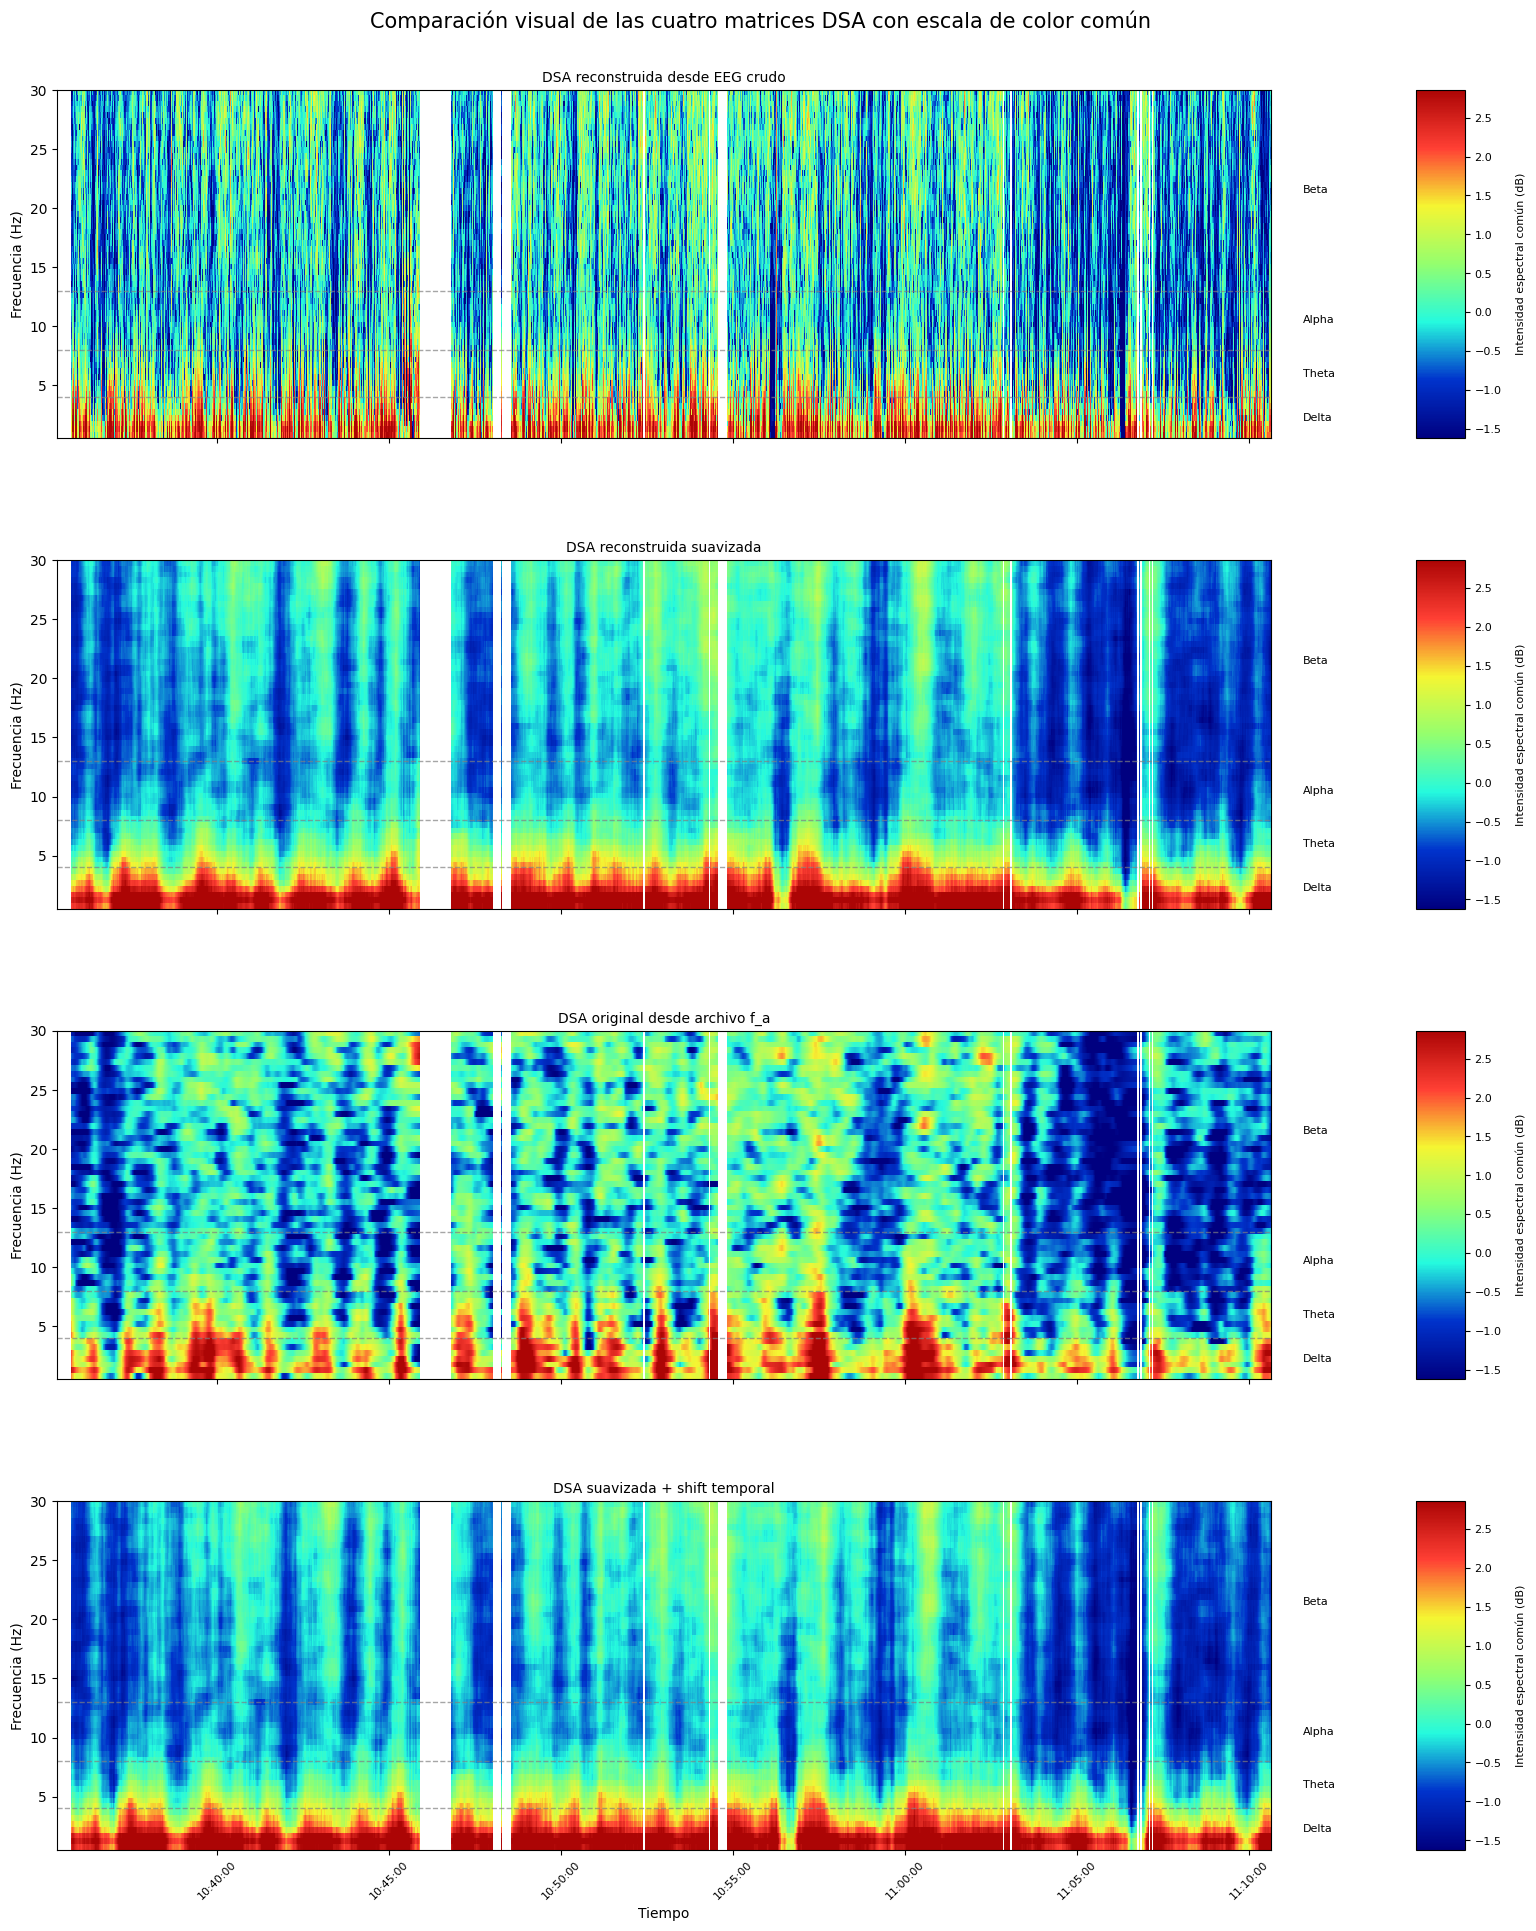

In [30]:
paneles = [
    {
        "tiempo": tiempo_eeg,
        "frecuencias": frecuencias_c1,
        "matriz": matriz_eeg_z,
        "norm": norm_z_comun,
        "cmap": cmap_z_comun,
        "df_merge": df_merge_eeg,
        "titulo": "DSA reconstruida desde EEG crudo",
        "etiqueta_colorbar": "Intensidad espectral común (dB)",
        "mask_total": mask_comun,
        "mostrar_sef": False,
        "mostrar_mef": False
    },
    {
        "tiempo": tiempo_eeg,
        "frecuencias": frecuencias_c1,
        "matriz": matriz_opt_z,
        "norm": norm_z_comun,
        "cmap": cmap_z_comun,
        "df_merge": df_merge_suav,
        "titulo": "DSA reconstruida suavizada",
        "etiqueta_colorbar": "Intensidad espectral común (dB)",
        "mask_total": mask_comun,
        "mostrar_sef": False,
        "mostrar_mef": False
    },
    {
        "tiempo": tiempo_fa_unilat,
        "frecuencias": dsa_fa_plot.columns.astype(float),
        "matriz": matriz_fa_z,
        "norm": norm_z_comun,
        "cmap": cmap_z_comun,
        "df_merge": df_merge_hor,
        "titulo": "DSA original desde archivo f_a",
        "etiqueta_colorbar": "Intensidad espectral común (dB)",
        "mask_total": mask_comun,
        "mostrar_sef": False,
        "mostrar_mef": False
    },
    {
        "tiempo": tiempo_eeg,
        "frecuencias": frecuencias_c1,
        "matriz": matriz_opt_desfase_z,
        "norm": norm_z_comun,
        "cmap": cmap_z_comun,
        "df_merge": df_merge_suav_shift_full,
        "titulo": "DSA suavizada + shift temporal",
        "etiqueta_colorbar": "Intensidad espectral común (dB)",
        "mask_total": mask_comun,
        "mostrar_sef": False,
        "mostrar_mef": False
    }
]

fig_grid, axes_grid = fun_dsa.plot_cuadricula_4_dsa(
    paneles,
    titulo_general="Comparación visual de las cuatro matrices DSA con escala de color común"
)

### Resultados

##### DSA reconstruida directamente desde EEG crudo
Ruidosa y con bastante variabilidad segundo a segundo. Estriada y vertical. Con mucho detalle local respecto a la DSA del BIS.

##### DSA con suavizado temporal
Reduce variabilidad local. Aproxima el comportamiento interno del monitor. Reproduce mejor la continuidad de las zonas, el aspecto general y los cambios a lo largo del tiempo.

##### DSA con desplazamiento temporal adicional
No modifica la estructura espectral pero permite evaluar si determinados eventos quedan mejor alineados respecto a la referencia exportada por el BIS.

# Resumen métricas
Las métricas se calcularon sobre matrices normalizadas mediante z-score global, con el objetivo de comparar la similitud de los patrones espectrales independientemente de las diferencias absolutas de escala.

La comparación incluyó la DSA reconstruida directa, la DSA suavizada temporalmente y la DSA suavizada con desplazamiento temporal.

In [31]:
def calcular_metricas_con_original(nombre, dsa_original, dsa_comparar):
    """
    Calcula métricas entre la DSA original f_a y otra DSA reconstruida.

    Las matrices se:
    1. igualan en columnas y longitud,
    2. normalizan con z-score global,
    3. comparan usando MAE, RMSE, bias, Pearson y Spearman.

    nombre:
        etiqueta del método comparado.
    """

    # 1) Asegurar mismas columnas, mismo orden y misma longitud
    A, B = fun_dsa.preparar_matrices_para_comparacion(
        dsa_original,
        dsa_comparar
    )

    # 2) Normalizar ambas matrices para comparar patrones
    A_z = fun_dsa.zscore_global(A)
    B_z = fun_dsa.zscore_global(B)

    # 3) Calcular métricas globales
    met = fun_dsa.comparar_dsa_global(A_z, B_z)

    return {
        "comparacion": nombre,
        "n_valores": met["n_valores_comparados"],
        "Pearson": met["Pearson"],
        "Spearman": met["Spearman"],
        "MAE": met["MAE"],
        "RMSE": met["RMSE"],
        "bias": met["bias_B_menos_A"]
    }

In [32]:
tabla_metricas_dsa = pd.DataFrame([
    calcular_metricas_con_original(
        nombre="Original f_a vs reconstruida EEG",
        dsa_original=dsa_fa_plot,
        dsa_comparar=dsa_eeg_directa_plot
    ),
    calcular_metricas_con_original(
        nombre="Original f_a vs reconstruida suavizada",
        dsa_original=dsa_fa_plot,
        dsa_comparar=dsa_eeg_suav_plot
    ),
    calcular_metricas_con_original(
        nombre="Original f_a vs suavizada + shift",
        dsa_original=dsa_fa_plot,
        dsa_comparar=dsa_eeg_suav_shift_full
    )
])

tabla_metricas_dsa = tabla_metricas_dsa.round(4)

tabla_metricas_dsa

,comparacion,n_valores,Pearson,Spearman,MAE,RMSE,bias
0,Original f_a vs reconstruida EEG,118380,0.3683,0.2941,0.8753,1.1240,-0.0
1,Original f_a vs reconstruida suavizada,118380,0.7141,0.6750,0.5747,0.7562,0.0
2,Original f_a vs suavizada + shift,118380,0.7588,0.7355,0.5287,0.6945,0.0


# Pruebas exploratorias
Variantes adicionales de reconstrucción:
 - Uso de la función ShortTimeFFT
 - Uso de distintas combinaciones de canales
 - Suavizado frecuencial
 - Individual y en combinación con distintos suavizados temporales y shifts temporales
 
No se reflejan mejoras relevantes en las métricas de similitud.

Mantenemos la reconstrucción basada en Welch:
 - más simple, 
 - interpretable y 
 - suficiente para generar una matriz tiempo-frecuencia comparable.

# Cálculo de intensidad por banda
Calcula características visuales por banda a partir de una DSA en dB.

Porcentaje relativo de intensidad espectral en dB por banda. Está calculado sobre la DSA en escala logarítmica.

In [33]:
def calcular_porcentaje_db_por_banda(dsa_db, frecuencias):
    """
    Calcular porcentajes relativos por banda usando la suma de valores en dB
    métrica descriptiva de intensidad en dB de la DSA
    
    Parámetros:
     - dsa_db: la matriz DSA en decibelios. 
               forma tiempo x frecuencia, filas=segundos y columnas=frecuencias
               
     - frecuencias: vector con las frecuencias correspondientes a las columnas de la DSA
     
    Devuelve:
     - df: DataFrame con los porcentajes por banda en cada segundo.
    """

    # convertir el dF de la dsa en un array de numpy numérico
    matriz = np.asarray(dsa_db, dtype=float)
    # convertir el vector de frecuencias en un array
    freqs = np.asarray(frecuencias, dtype=float)

    """ 
    máscara booleana para seleccionar las columnas que pertenecen cada banda 
    cada una de las categorías es un array con True y False 
    True indica que la columna pertenece a delta, False no pertenece
    """
    delta = (freqs >= 0.5) & (freqs < 4)
    theta = (freqs >= 4) & (freqs < 8)
    alpha = (freqs >= 8) & (freqs < 13)
    beta  = (freqs >= 13) & (freqs <= 30)

    """
    vector de suma total de intensidad en dB para cada fila (cada segundo) de la matriz.Total de potencia en ese segundo
    axis=1: suma por columnas, es decir, suma todas las frecuencias de cada segundo
    np.nansum: ignora los NaN para respetar las bandas blancas
    """
    total = np.nansum(matriz, axis=1)

    """ 
    evitar que salgan los avisos cuando alguna fila esté a 0 o sea todo NaN
    los resultados problemáticos se quedan como NaN
    """
    with np.errstate(divide="ignore", invalid="ignore"):
        """ 
        matriz[:, delta]: de todas las filas, selecciona las columnas de la banda delta
        
        np.nansum(matriz[:, delta], axis=1): suma los valores de delta en cada segundo ignorando NaN
        
        * 100 / total: convierte la suma en porcentaje respecto al total de todas las frecuencias
        
        frac_delta: porcentaje de intensidad dB correspondiente a delta en cada segundo
        """
        porcentaje_delta = np.nansum(matriz[:, delta], axis=1) * 100 / total
        porcentaje_theta = np.nansum(matriz[:, theta], axis=1) * 100 / total
        porcentaje_alpha = np.nansum(matriz[:, alpha], axis=1) * 100 / total
        porcentaje_beta  = np.nansum(matriz[:, beta], axis=1) * 100 / total

    # dF para guardar resultados
    df = pd.DataFrame({
        "delta_%_db": porcentaje_delta,
        "theta_%_db": porcentaje_theta,
        "alpha_%_db": porcentaje_alpha,
        "beta_%_db": porcentaje_beta
    })

    return df

In [34]:
df_bandas_fa_db = calcular_porcentaje_db_por_banda(
    dsa_db=dsa_fa_plot,
    frecuencias=dsa_fa_plot.columns.astype(float)
)

df_bandas_eeg_db = calcular_porcentaje_db_por_banda(
    dsa_db=dsa_eeg_directa_plot,
    frecuencias=frecuencias_c1
)

df_bandas_suav_db = calcular_porcentaje_db_por_banda(
    dsa_db=dsa_eeg_suav_plot,
    frecuencias=frecuencias_c1
)

df_bandas_shift_db = calcular_porcentaje_db_por_banda(
    dsa_db=dsa_eeg_suav_shift_full,
    frecuencias=frecuencias_c1
)

"""
Para cada matriz, calcula el valor medio de delta_%_db, theta_%_db, alpha_%_db y beta_%_db a lo largo de 
todos los segundos válidos del registro.
Resumen global: media temporal del porcentaje relativo en dB de cada banda para cada matriz
"""
resumen_bandas_db = pd.DataFrame({
    "matriz": [
        "DSA original f_a",
        "DSA reconstruida EEG",
        "DSA reconstruida suavizada",
        "DSA suavizada + shift"
    ],
    "delta_%_db_media": [
        df_bandas_fa_db["delta_%_db"].mean(),
        df_bandas_eeg_db["delta_%_db"].mean(),
        df_bandas_suav_db["delta_%_db"].mean(),
        df_bandas_shift_db["delta_%_db"].mean()
    ],
    "theta_%_db_media": [
        df_bandas_fa_db["theta_%_db"].mean(),
        df_bandas_eeg_db["theta_%_db"].mean(),
        df_bandas_suav_db["theta_%_db"].mean(),
        df_bandas_shift_db["theta_%_db"].mean()
    ],
    "alpha_%_db_media": [
        df_bandas_fa_db["alpha_%_db"].mean(),
        df_bandas_eeg_db["alpha_%_db"].mean(),
        df_bandas_suav_db["alpha_%_db"].mean(),
        df_bandas_shift_db["alpha_%_db"].mean()
    ],
    "beta_%_db_media": [
        df_bandas_fa_db["beta_%_db"].mean(),
        df_bandas_eeg_db["beta_%_db"].mean(),
        df_bandas_suav_db["beta_%_db"].mean(),
        df_bandas_shift_db["beta_%_db"].mean()
    ],
})

resumen_bandas_db

,matriz,delta_%_db_media,theta_%_db_media,alpha_%_db_media,beta_%_db_media
0,DSA original f_a,12.762995,13.597756,16.353404,57.285845
1,DSA reconstruida EEG,13.250368,13.602175,16.152457,56.995000
2,DSA reconstruida suavizada,13.267471,13.614334,16.144722,56.973473
3,DSA suavizada + shift,13.267762,13.609876,16.139549,56.982813


In [ ]:
"""print("DSA original f_a")
display(df_bandas_fa_db.describe())

print("DSA reconstruida EEG")
display(df_bandas_eeg_db.describe())

print("DSA reconstruida suavizada")
display(df_bandas_suav_db.describe())

print("DSA suavizada + shift")
display(df_bandas_shift_db.describe())"""

In [ ]:
def resumen_descriptivo_bandas(df_bandas, nombre_matriz):
    resumen = df_bandas.describe().T
    resumen.insert(0, "matriz", nombre_matriz)
    resumen = resumen.reset_index().rename(columns={"index": "banda"})
    return resumen

resumen_total_bandas_db = pd.concat([
    resumen_descriptivo_bandas(df_bandas_fa_db, "DSA original f_a"),
    resumen_descriptivo_bandas(df_bandas_eeg_db, "DSA reconstruida EEG"),
    resumen_descriptivo_bandas(df_bandas_suav_db, "DSA reconstruida suavizada"),
    resumen_descriptivo_bandas(df_bandas_shift_db, "DSA suavizada + shift"),
], ignore_index=True)

#resumen_total_bandas_db